# Consolidating the data

In [27]:
# importing resources

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot  as plt
import geopandas as gpd
import shapely as sh
import missingno as mn

In [28]:
# read all relevant files

simple_summary = pd.read_csv(r"../data/raw/iucn/simple_summary.csv", encoding='utf-8')
all_other_fields = pd.read_csv(r"../data/raw/iucn/all_other_fields.csv", encoding='utf-8')
habitats = pd.read_csv(r"../data/raw/iucn/habitats.csv", encoding='utf-8')
threats = pd.read_csv(r"../data/raw/iucn/threats.csv", encoding='utf-8')
usetrade = pd.read_csv(r"../data/raw/iucn/usetrade.csv", encoding='utf-8')
conservation_needed = pd.read_csv(r"../data/raw/iucn/conservation_needed.csv", encoding='utf-8')
research_needed = pd.read_csv(r"../data/raw/iucn/research_needed.csv", encoding='utf-8')
countries = pd.read_csv(r"../data/raw/iucn/countries.csv", encoding='utf-8')

datasets = {
    'simple_summary': simple_summary,
    'countries': countries,
    'habitats': habitats,
    'threats': threats,
    'research_needed': research_needed,
    'conservation_needed': conservation_needed,
    'usetrade': usetrade,
    'all_other_fields': all_other_fields,
}

for name, df in datasets.items():
    print(f"{name:25s} {df.shape[0]:>7,} rows, {df.shape[1]:>2} columns")

simple_summary             41,949 rows, 19 columns
countries                 431,396 rows,  9 columns
habitats                  109,594 rows,  8 columns
threats                    88,999 rows, 15 columns
research_needed            82,263 rows,  6 columns
conservation_needed        50,414 rows,  6 columns
usetrade                   18,524 rows,  9 columns
all_other_fields           41,949 rows, 34 columns


## Missingness

In [29]:
all_tables = [simple_summary, all_other_fields, habitats, threats, usetrade, conservation_needed, research_needed, countries]

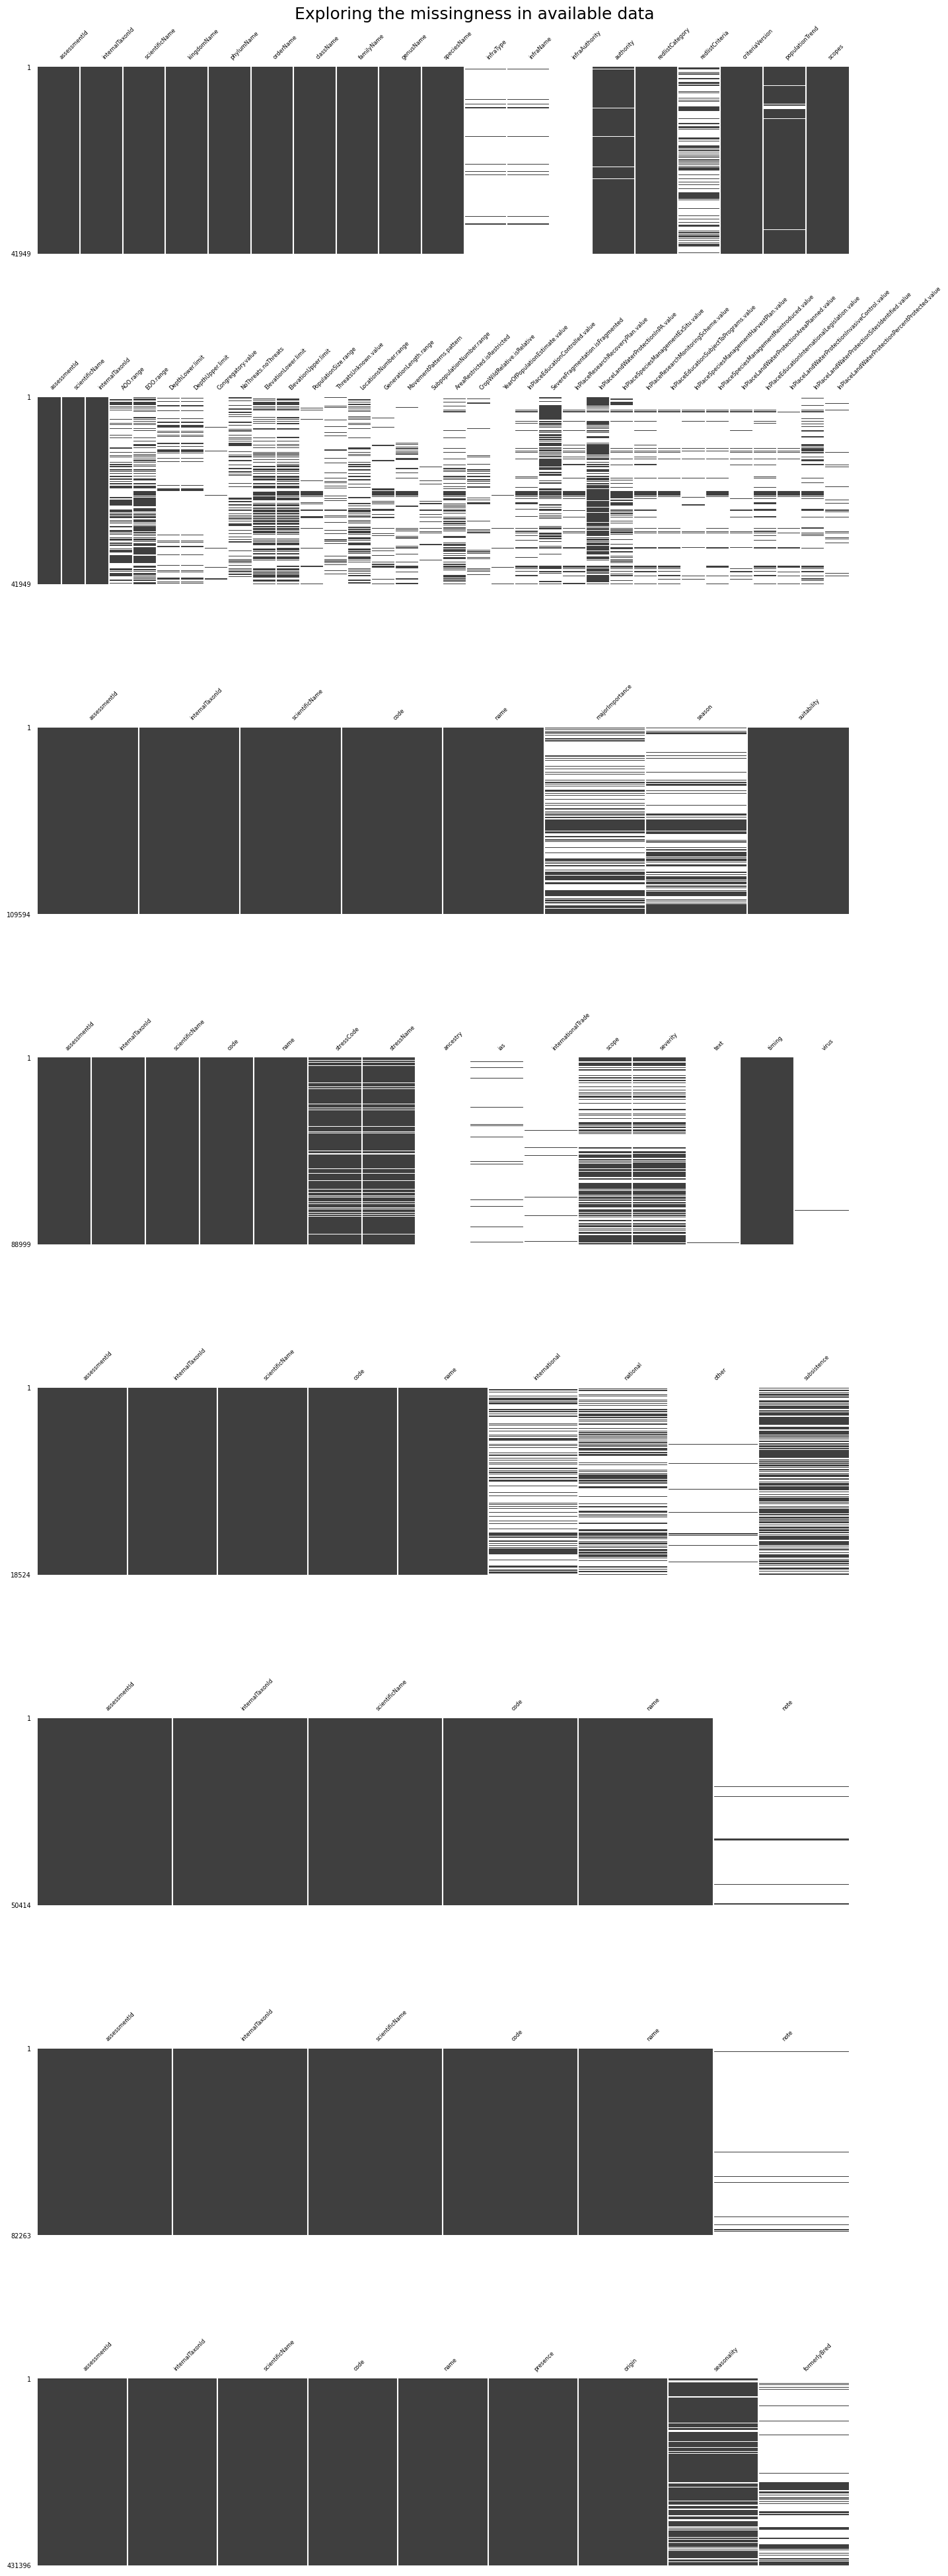

In [30]:
fig, axs = plt.subplots(len(all_tables), figsize=(15,40))

for i, table in enumerate(all_tables):
    mn.matrix(table, ax=axs[i], sparkline=False, fontsize=6)

plt.suptitle('Exploring the missingness in available data', fontsize=18)
plt.tight_layout(pad=3)
plt.show()

In [31]:
simple_summary.head()

,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,infraType,infraName,infraAuthority,authority,redlistCategory,redlistCriteria,criteriaVersion,populationTrend,scopes
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,NaN,NaN,NaN,"(Bonnaterre, 1788)",Near Threatened,A2bd,3.1,Decreasing,Global
1,500969,11200,Lamna nasus,ANIMALIA,CHORDATA,LAMNIFORMES,CHONDRICHTHYES,LAMNIDAE,Lamna,nasus,NaN,NaN,NaN,"(Bonnaterre, 1788)",Vulnerable,A2bd,3.1,Decreasing,Global
2,507158,232775771,Macrochelys temminckii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,CHELYDRIDAE,Macrochelys,temminckii,NaN,NaN,NaN,"(Troost in Harlan, 1835)",Endangered,A2bcd+4bcd,3.1,Decreasing,Global
3,508210,12696,Malacochersus tornieri,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,TESTUDINIDAE,Malacochersus,tornieri,NaN,NaN,NaN,"(Siebenrock, 1903)",Critically Endangered,A4abcd,3.1,Decreasing,Global
4,508612,12776,Mantella aurantiaca,ANIMALIA,CHORDATA,ANURA,AMPHIBIA,MANTELLIDAE,Mantella,aurantiaca,NaN,NaN,NaN,"Mocquard, 1900",Endangered,"B1ab(ii,iii,v)+2ab(ii,iii,v)",3.1,Decreasing,Global


In [32]:
# create the main df to which all others will be joined

full_df = simple_summary.drop(columns=["infraType","infraName","infraAuthority","authority","criteriaVersion","scopes",'redlistCriteria'])

full_df.head()

,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,redlistCategory,populationTrend
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,Near Threatened,Decreasing
1,500969,11200,Lamna nasus,ANIMALIA,CHORDATA,LAMNIFORMES,CHONDRICHTHYES,LAMNIDAE,Lamna,nasus,Vulnerable,Decreasing
2,507158,232775771,Macrochelys temminckii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,CHELYDRIDAE,Macrochelys,temminckii,Endangered,Decreasing
3,508210,12696,Malacochersus tornieri,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,TESTUDINIDAE,Malacochersus,tornieri,Critically Endangered,Decreasing
4,508612,12776,Mantella aurantiaca,ANIMALIA,CHORDATA,ANURA,AMPHIBIA,MANTELLIDAE,Mantella,aurantiaca,Endangered,Decreasing


In [33]:
full_df['populationTrend'].unique()

<StringArray>
['Decreasing', 'Unknown', 'Stable', 'Increasing', nan]
Length: 5, dtype: str

In [34]:
# For population trends, there's already a value for 'unknown'...

full_df['populationTrend'] = full_df['populationTrend'].fillna('Unknown')
full_df['populationTrend'].unique()

<StringArray>
['Decreasing', 'Unknown', 'Stable', 'Increasing']
Length: 4, dtype: str

In [ ]:
# select the columns from each additional csv and rename it for merging

habitats = habitats[['internalTaxonId', 'code', 'name']].rename(columns={'code':'habitatCode', 'name':'habitatName'})

threats = threats[['internalTaxonId', 'code', 'name']].rename(columns={'code':'threatCode','name':'threatName'})

usetrade = usetrade[['internalTaxonId', 'code', 'name']].rename(columns={'code':'useCode', 'name':'useName'})

conservation_needed = conservation_needed[['internalTaxonId', 'code', 'name']].rename(columns={'code':'conservationNeededCode', 'name':'conservationNeededName'})

research_needed = research_needed[['internalTaxonId', 'code', 'name']].rename(columns={'code':'researchNeededCode','name':'researchNeededName'})

countries = countries[['internalTaxonId', 'code', 'name', 'presence', 'origin']].rename(columns={'code':'countryCode', 'name':'countryName'})

In [51]:
countries = countries.dropna(axis=1, how='any')

In [52]:
all_tables = [full_df, habitats, threats, usetrade, conservation_needed, research_needed, countries]

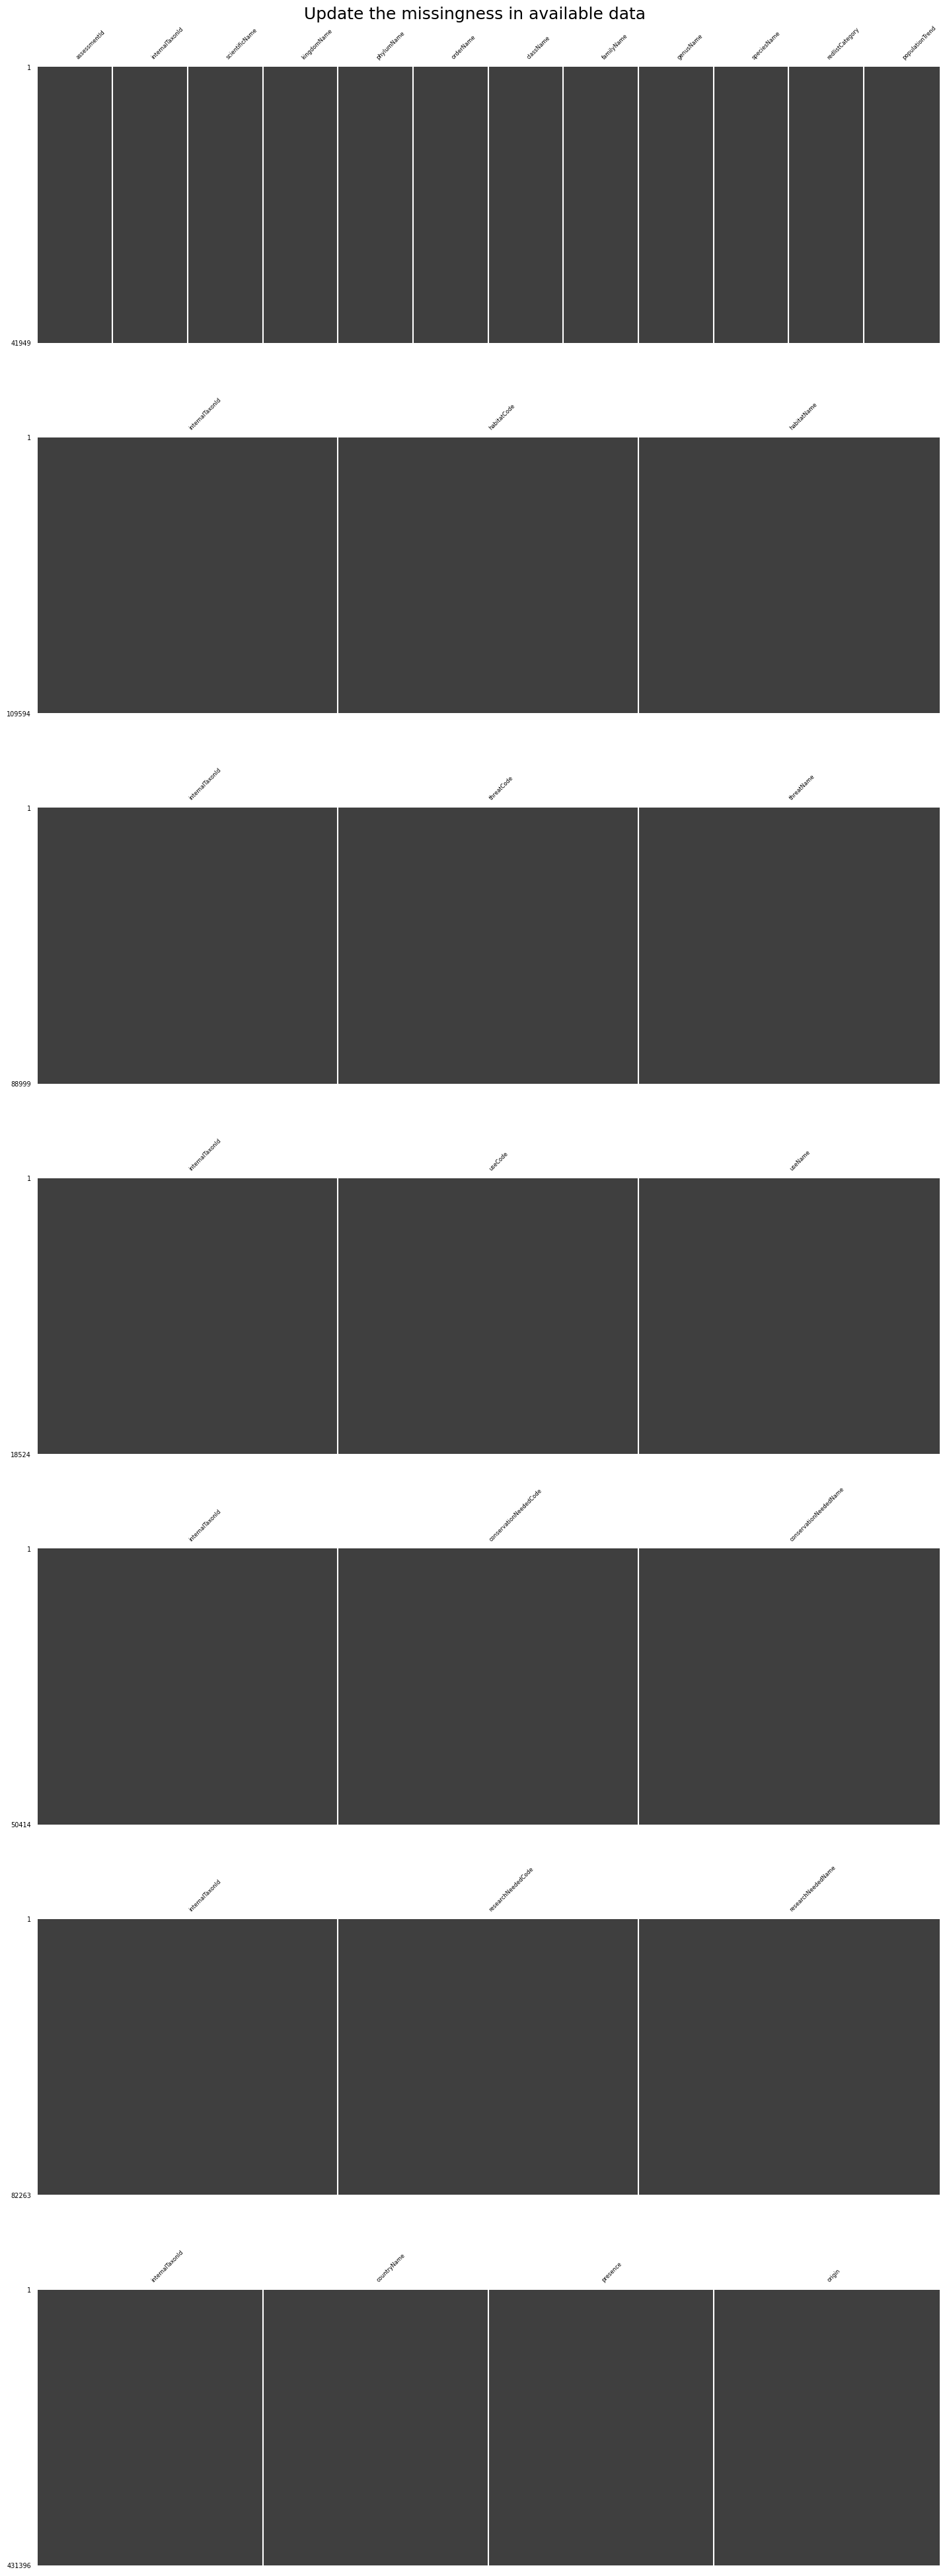

In [53]:
fig, axs = plt.subplots(len(all_tables), figsize=(15,40))

for i, table in enumerate(all_tables):
    mn.matrix(table, ax=axs[i], sparkline=False, fontsize=6)

plt.suptitle('Update the missingness in available data', fontsize=18)
plt.tight_layout(pad=3)
plt.show()

### Duplicates

In [55]:
print(f"There are {full_df['internalTaxonId'].duplicated().sum()} duplicated rows in the main df")

There are 2925 duplicated rows in the main df


In [56]:
# See which ones are duplicated and how many times
print(full_df['internalTaxonId'].value_counts())

internalTaxonId
155675       8
59811        8
59897        8
59859        8
59965        8
            ..
5587         1
286119865    1
134817215    1
197913       1
201750       1
Name: count, Length: 39024, dtype: int64


In [57]:
full_df = full_df.drop_duplicates(subset='internalTaxonId', keep='first')
print(f"There are {full_df['internalTaxonId'].duplicated().sum()} duplicated rows")

There are 0 duplicated rows


## Export files for EDA

In [58]:
# save filtered tables to csv

full_df.to_csv('../data/processed/base_taxa.csv', index=False)
habitats.to_csv('../data/processed/habitats.csv', index=False)
threats.to_csv('../data/processed/threats.csv', index=False)
usetrade.to_csv('../data/processed/uses.csv', index=False)
conservation_needed.to_csv('../data/processed/conservation_needed.csv', index=False)
research_needed.to_csv('../data/processed/research_needed.csv', index=False)
countries.to_csv('../data/processed/countries.csv', index=False)